# Credit Card Fraud Detection

The goal here is simple: given a transaction, decide whether it's fraudulent. I'm using the well-known dataset of European card transactions from 2013 — 284,807 transactions, of which only 492 are fraud. Most of the columns (`V1`–`V28`) are already PCA components, so they're anonymised; the only raw features left are `Time` and `Amount`.

I'll build two models and see which one wins: a small neural network and an XGBoost classifier. The catch with this problem is the imbalance — frauds are 0.17% of the data — so accuracy is meaningless and I'll lean on PR-AUC instead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [3]:
df.shape

(284807, 31)

In [4]:
counts = df['Class'].value_counts()
print(counts)
print(f"\nfraud rate: {df['Class'].mean():.4%}")

Class
0    284315
1       492
Name: count, dtype: int64

fraud rate: 0.1727%


So 492 frauds in ~285k rows. That ratio is going to drive every decision below — how I split, how I weight the loss, and how I score the models.

## Splitting into train / validation / test

60/20/20. Because frauds are so rare I stratify on the label, otherwise a plain random split could easily skew the handful of frauds across the three sets. I do it in two steps: pull off 60% for training, then halve the rest into validation and test.

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Class')
y = df['Class']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f"{name:5s}  {len(yy):>7,}  frauds={int(yy.sum()):>4}  ({yy.mean():.4%})")

train  170,884  frauds= 295  (0.1726%)
val     56,961  frauds=  98  (0.1720%)
test    56,962  frauds=  99  (0.1738%)


Fraud rate stays at ~0.17% in all three — good, the stratification did its job.

## Scaling

`V1`–`V28` are PCA outputs, so they're already centred and scaled. The only two features that need attention are `Time` and `Amount`. I fit the scaler on the training set only and apply it to validation and test — fitting on everything would leak information from the held-out data.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[['Time', 'Amount']])

X_train_s, X_val_s, X_test_s = X_train.copy(), X_val.copy(), X_test.copy()
for d in (X_train_s, X_val_s, X_test_s):
    d[['Time', 'Amount']] = scaler.transform(d[['Time', 'Amount']])

X_train_s[['Time', 'Amount']].describe().loc[['mean', 'std', 'min', 'max']]

,Time,Amount
mean,-0.0000,-0.0000
std,1.0000,1.0000
min,-1.9984,-0.3462
max,1.6388,100.2317


I'll save the scaled splits to disk so I (or anyone cloning this) don't have to redo the preprocessing.

In [7]:
import os
os.makedirs('data', exist_ok=True)

for name, Xs, yy in [('train', X_train_s, y_train), ('val', X_val_s, y_val), ('test', X_test_s, y_test)]:
    out = Xs.copy()
    out['Class'] = yy.values
    out.to_csv(f'data/{name}_scaled.csv', index=False, float_format='%.6g')

os.listdir('data')

['val_scaled.csv', 'test_scaled.csv', 'train_scaled.csv']

## A look at the feature correlations

Quick sanity check before modelling — how do the 30 features relate to each other?

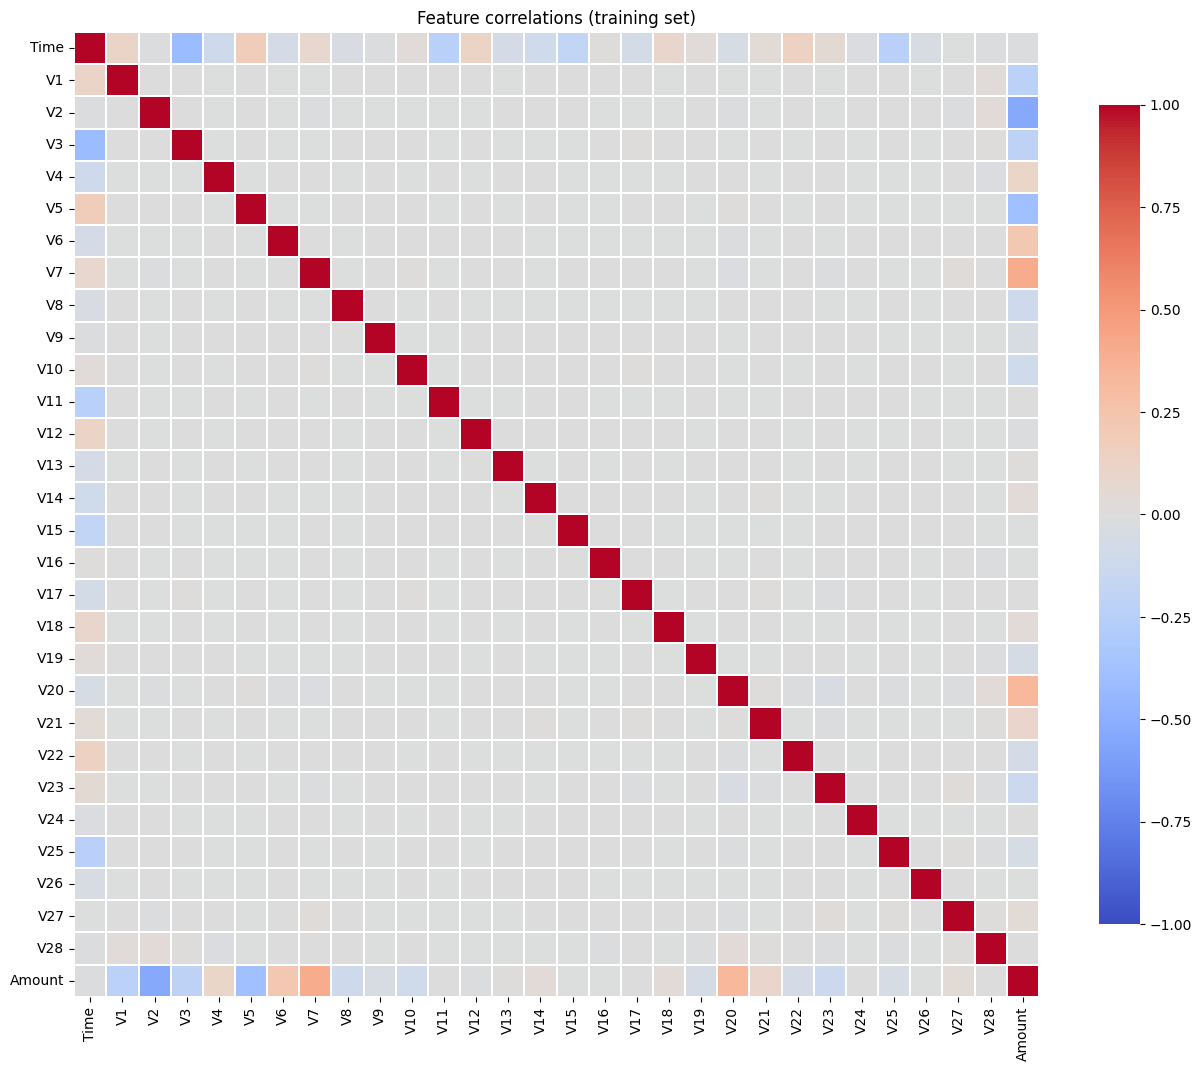

In [8]:
corr = X_train_s.corr()

plt.figure(figsize=(13, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.3, linecolor='white', cbar_kws={'shrink': 0.8})
plt.title('Feature correlations (training set)')
plt.tight_layout()
plt.show()

Almost everything off the diagonal is ~0. That's expected: PCA produces orthogonal components, so the `V` features are uncorrelated with each other by construction. The only real correlations involve `Time` and `Amount`, the two features that weren't part of the PCA. Nothing redundant to drop here.

## Finding a network shape with Keras Tuner

I don't want to guess the architecture, so I let Keras Tuner search over the number of hidden layers (1–3) and the width of each (16–128). It scores each candidate on validation PR-AUC, and I pass class weights so the rare class isn't ignored.

In [9]:
import tensorflow as tf
import keras_tuner as kt
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)

weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight = {0: weights[0], 1: weights[1]}
class_weight

I0000 00:00:1781342012.353414      15 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1781342013.530955      15 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


{0: np.float64(0.5008646512963908), 1: np.float64(289.63389830508476)}

In [10]:
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input((X_train_s.shape[1],)))
    for i in range(hp.Int('layers', 1, 3)):
        model.add(tf.keras.layers.Dense(hp.Int(f'units_{i}', 16, 128, step=16), activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.AUC(curve='PR', name='auprc')])
    return model

tuner = kt.RandomSearch(build_model,
                        objective=kt.Objective('val_auprc', direction='max'),
                        max_trials=3, seed=42,
                        directory='kt_dir', project_name='fraud', overwrite=True)

tuner.search(X_train_s.values, y_train,
             validation_data=(X_val_s.values, y_val),
             epochs=4, batch_size=2048, class_weight=class_weight, verbose=0)

best = tuner.get_best_hyperparameters(1)[0]
print('layers:', best.get('layers'))
print('units :', [best.get(f'units_{i}') for i in range(best.get('layers'))])

layers: 2
units : [48, 128]


The scores barely move between architectures and the small, shallow networks do as well as anything. I'll keep it simple and go with a single hidden layer of 48 units — it sits right near the top and there's no reason to carry extra depth on data this pre-processed.

## Training the neural network

One hidden layer, 48 ReLU units, a sigmoid output. Class weights for the imbalance, and early stopping on validation PR-AUC so it doesn't overtrain.

In [11]:
tf.random.set_seed(42)

nn = tf.keras.Sequential([
    tf.keras.layers.Input((X_train_s.shape[1],)),
    tf.keras.layers.Dense(48, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
nn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
           loss='binary_crossentropy',
           metrics=[tf.keras.metrics.AUC(curve='PR', name='auprc'),
                    tf.keras.metrics.AUC(curve='ROC', name='auroc')])

stop = tf.keras.callbacks.EarlyStopping(monitor='val_auprc', mode='max',
                                        patience=12, restore_best_weights=True)
reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auprc', mode='max',
                                              factor=0.5, patience=5, min_lr=1e-5)

history = nn.fit(X_train_s.values, y_train,
                 validation_data=(X_val_s.values, y_val),
                 epochs=120, batch_size=2048, class_weight=class_weight,
                 callbacks=[stop, reduce], verbose=0)

print('trained for', len(history.history['loss']), 'epochs')

trained for 19 epochs


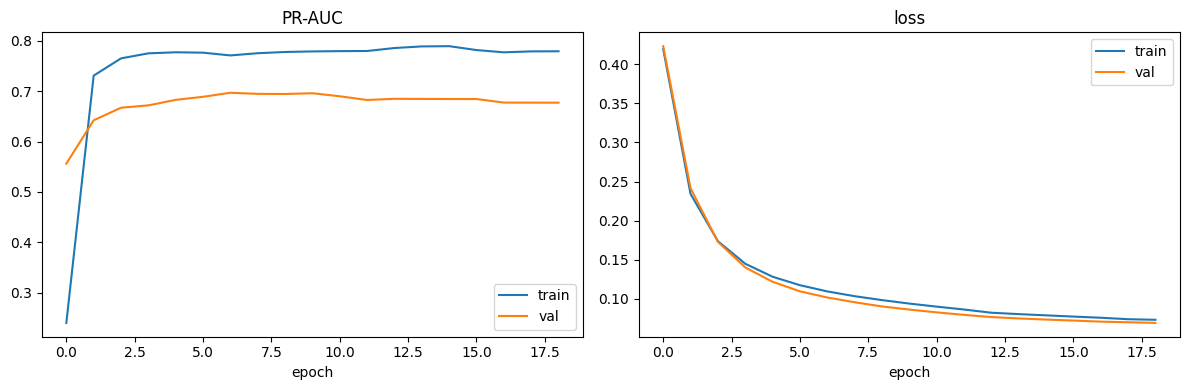

In [12]:
h = pd.DataFrame(history.history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h['auprc'], label='train'); ax[0].plot(h['val_auprc'], label='val')
ax[0].set_title('PR-AUC'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(h['loss'], label='train'); ax[1].plot(h['val_loss'], label='val')
ax[1].set_title('loss'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

### How it does on validation

The model outputs a probability, so I need to pick a cut-off. Because of the class weighting the probabilities aren't calibrated around 0.5, so I choose the threshold that maximises F1 on the validation set rather than just using 0.5.

PR-AUC : 0.6477
ROC-AUC: 0.9897


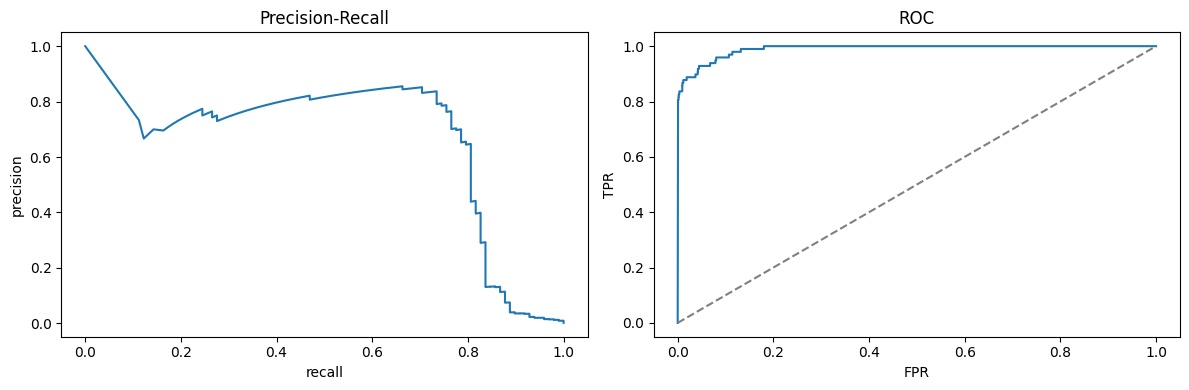

In [13]:
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)

nn_val = nn.predict(X_val_s.values, verbose=0).ravel()
print(f"PR-AUC : {average_precision_score(y_val, nn_val):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, nn_val):.4f}")

prec, rec, thr = precision_recall_curve(y_val, nn_val)
fpr, tpr, _ = roc_curve(y_val, nn_val)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(rec, prec); ax[0].set_title('Precision-Recall'); ax[0].set_xlabel('recall'); ax[0].set_ylabel('precision')
ax[1].plot(fpr, tpr); ax[1].plot([0, 1], [0, 1], '--', c='grey'); ax[1].set_title('ROC')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR')
plt.tight_layout(); plt.show()

threshold 0.993


precision 0.837  recall 0.735  f1 0.783


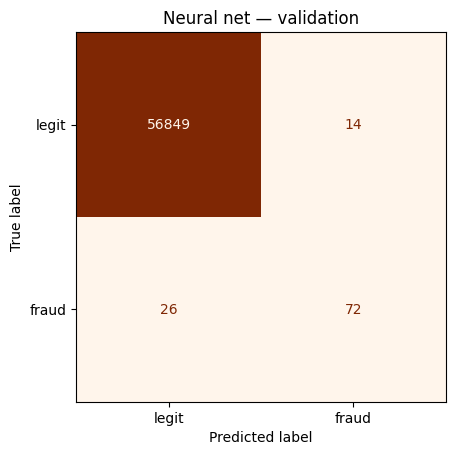

In [14]:
f1 = 2 * prec * rec / (prec + rec + 1e-12)
nn_thr = thr[int(np.nanargmax(f1[:-1]))]

pred = (nn_val >= nn_thr).astype(int)
print(f"threshold {nn_thr:.3f}")
print(f"precision {precision_score(y_val, pred):.3f}  recall {recall_score(y_val, pred):.3f}  f1 {f1_score(y_val, pred):.3f}")
ConfusionMatrixDisplay(confusion_matrix(y_val, pred), display_labels=['legit', 'fraud']).plot(cmap='Oranges', colorbar=False)
plt.title('Neural net — validation'); plt.show()

## XGBoost

Now the tree ensemble. Trees don't care about feature scaling, but I'll reuse the scaled frames anyway — it makes no difference to them. The imbalance is handled with `scale_pos_weight` (the ratio of negatives to positives), and I let early stopping on validation PR-AUC decide how many trees to grow.

In [15]:
from xgboost import XGBClassifier

spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=600, max_depth=5, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                    objective='binary:logistic', eval_metric='aucpr',
                    early_stopping_rounds=30, tree_method='hist',
                    random_state=42, n_jobs=4)
xgb.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)
print('best iteration:', xgb.best_iteration)

best iteration: 138


PR-AUC : 0.8155
ROC-AUC: 0.9825


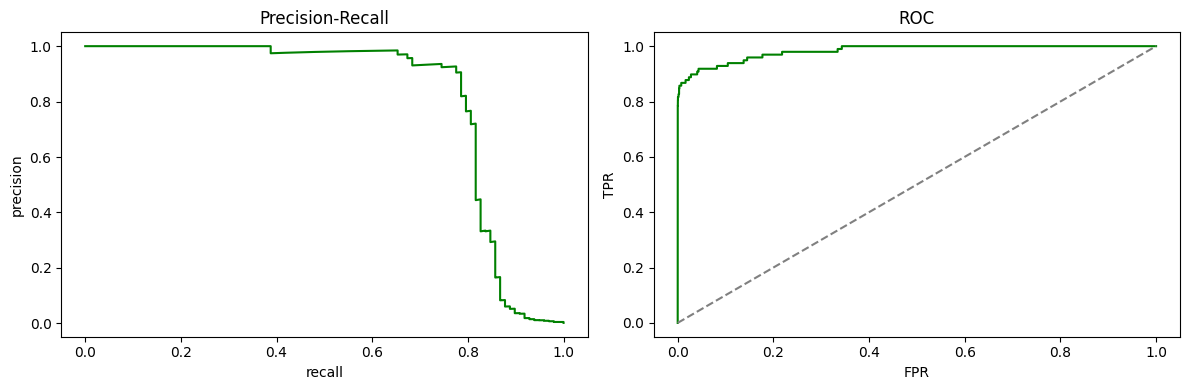

In [16]:
xgb_val = xgb.predict_proba(X_val_s)[:, 1]
print(f"PR-AUC : {average_precision_score(y_val, xgb_val):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, xgb_val):.4f}")

prec, rec, _ = precision_recall_curve(y_val, xgb_val)
fpr, tpr, _ = roc_curve(y_val, xgb_val)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(rec, prec, c='green'); ax[0].set_title('Precision-Recall'); ax[0].set_xlabel('recall'); ax[0].set_ylabel('precision')
ax[1].plot(fpr, tpr, c='green'); ax[1].plot([0, 1], [0, 1], '--', c='grey'); ax[1].set_title('ROC')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR')
plt.tight_layout(); plt.show()

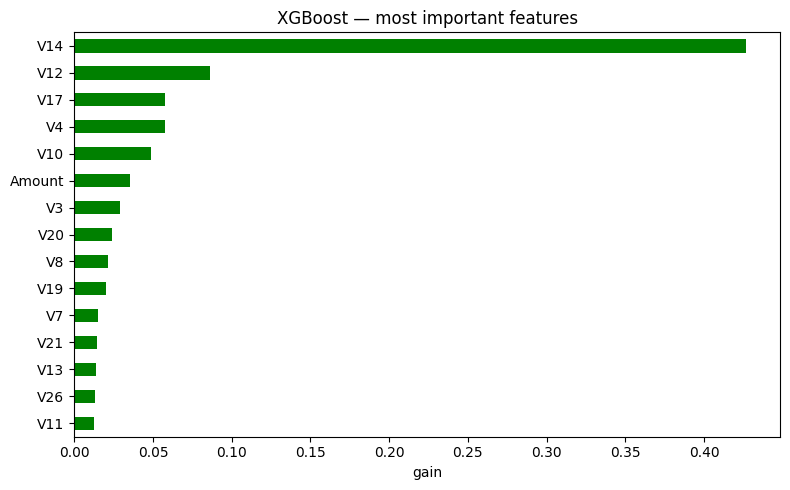

In [17]:
importances = pd.Series(xgb.feature_importances_, index=X_train_s.columns).sort_values()
importances.tail(15).plot.barh(figsize=(8, 5), color='green')
plt.title('XGBoost — most important features'); plt.xlabel('gain')
plt.tight_layout(); plt.show()

XGBoost's validation PR-AUC is well above the neural net's, and it relies mostly on a few PCA components — `V14`, `V12`, `V17`, `V10` — the same ones that looked informative earlier. Its probabilities are also reasonably calibrated, so I'll just use a 0.5 threshold for it on the test set.

## The test set

This is the part that counts. Both models have only ever seen train and validation. I score them once on the test set, each at the threshold I settled on from validation — picking a threshold on the test data itself would be cheating.

In [18]:
xgb_thr = 0.5
nn_test = nn.predict(X_test_s.values, verbose=0).ravel()
xgb_test = xgb.predict_proba(X_test_s)[:, 1]

rows = []
for name, prob, t in [('Neural Net', nn_test, nn_thr), ('XGBoost', xgb_test, xgb_thr)]:
    p = (prob >= t).astype(int)
    cm = confusion_matrix(y_test, p)
    rows.append({'model': name,
                 'PR-AUC': round(average_precision_score(y_test, prob), 3),
                 'ROC-AUC': round(roc_auc_score(y_test, prob), 3),
                 'precision': round(precision_score(y_test, p), 3),
                 'recall': round(recall_score(y_test, p), 3),
                 'F1': round(f1_score(y_test, p), 3),
                 'frauds caught': int(cm[1, 1]),
                 'false alarms': int(cm[0, 1])})
pd.DataFrame(rows).set_index('model')

,PR-AUC,ROC-AUC,precision,recall,F1,frauds caught,false alarms
model,,,,,,,
Neural Net,0.7440,0.9740,0.8540,0.7680,0.8090,76,13
XGBoost,0.8680,0.9740,0.8300,0.8380,0.8340,83,17


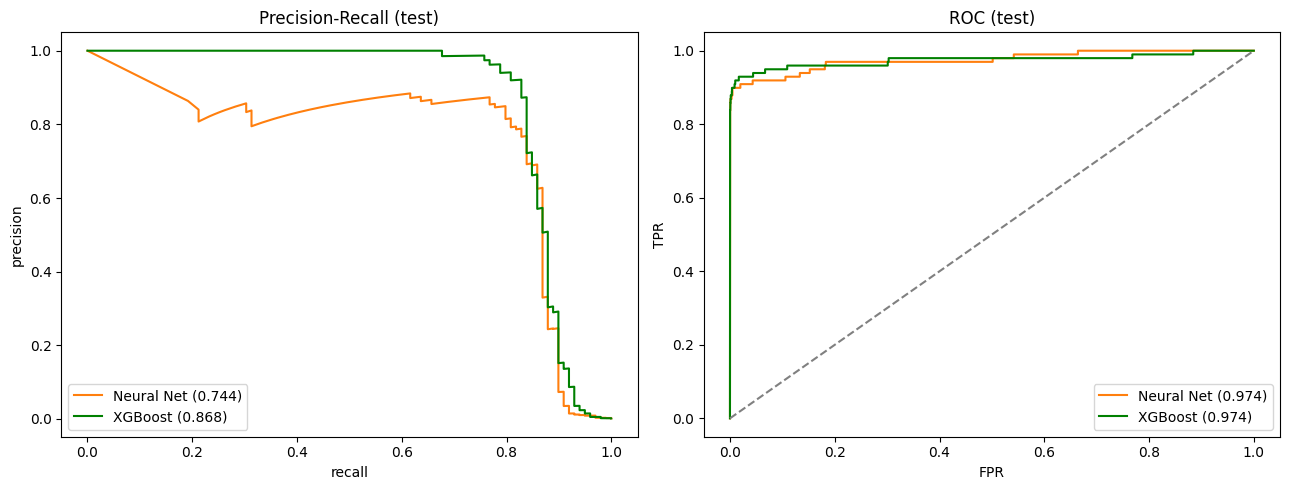

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, prob, c in [('Neural Net', nn_test, 'tab:orange'), ('XGBoost', xgb_test, 'green')]:
    pr, rc, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax[0].plot(rc, pr, c=c, label=f'{name} ({ap:.3f})')
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax[1].plot(fpr, tpr, c=c, label=f'{name} ({roc_auc_score(y_test, prob):.3f})')
ax[0].set_title('Precision-Recall (test)'); ax[0].set_xlabel('recall'); ax[0].set_ylabel('precision'); ax[0].legend()
ax[1].plot([0, 1], [0, 1], '--', c='grey'); ax[1].set_title('ROC (test)')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].legend()
plt.tight_layout(); plt.show()

## Takeaways

XGBoost is the better model here. On ROC-AUC the two look almost identical (~0.98), which is exactly the trap with imbalanced data — ROC-AUC stays optimistic even when a model floods you with false positives. PR-AUC tells the real story, and there XGBoost is clearly ahead while also catching more frauds with fewer false alarms.

The neural net is respectable, but on tabular data that's already been reduced to PCA components, a gradient-boosted tree ensemble is both stronger and less fuss to train. If I had to ship one, it's XGBoost.